In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print(df.shape)
df.head()

Saving hotel_bookings_clean.csv to hotel_bookings_clean.csv
(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Load libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Target variable: 0 = No cancellation, 1 = Cancellation
target = "is_canceled"

candidate_features = [
    "hotel",
    "lead_time",
    "adults",
    "children",
    "babies",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "customer_type",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "total_of_special_requests",
    "previous_cancellations",
    "booking_changes"
]

features = [c for c in candidate_features if c in df.columns]

data = df[features + [target]].copy()
data[target] = pd.to_numeric(data[target], errors="coerce")
data = data.dropna(subset=[target])
data = data[data[target].isin([0, 1])]
data[target] = data[target].astype(int)

X = data[features]
y = data[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 80% training, 20% testing; preserve target proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Number of predictors:", len(features))
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).rename("Proportion"))

Training observations: 95512
Testing observations: 23878
Number of predictors: 15

Training target distribution:
is_canceled
0    0.629586
1    0.370414
Name: Proportion, dtype: float64


2. Evaluate trees with varying maximum depths

In [4]:
depth_results = []

for depth in range(2, 21):
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    depth_results.append({
        "Max Depth": depth,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

depth_results = pd.DataFrame(depth_results)

display(depth_results.round(4))

# Select the depth with the highest test F1-score.
best_depth = int(
    depth_results.loc[depth_results["F1-score"].idxmax(), "Max Depth"]
)

print("Best depth by test F1-score:", best_depth)

,Max Depth,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,2,0.6764,0.9643,0.1313,0.2311,0.6663
1,3,0.6994,0.5770,0.7065,0.6352,0.7424
2,4,0.7586,0.6951,0.6205,0.6557,0.7901
3,5,0.7589,0.6958,0.6205,0.6560,0.8143
4,6,0.7723,0.7916,0.5231,0.6300,0.8285
5,7,0.7822,0.7543,0.6110,0.6751,0.8385
6,8,0.7916,0.8002,0.5828,0.6744,0.8442
7,9,0.7971,0.8008,0.6019,0.6873,0.8487
8,10,0.7996,0.8047,0.6061,0.6914,0.8523
9,11,0.8006,0.7933,0.6244,0.6988,0.8550


Best depth by test F1-score: 20


In [ ]:
Visualize the depth comparison

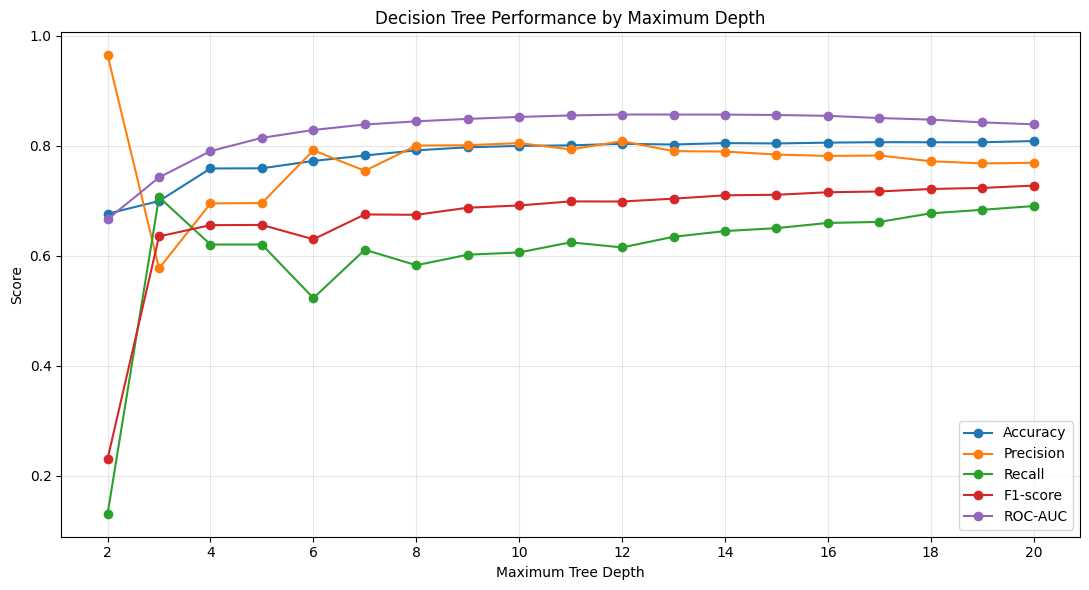

In [5]:
plt.figure(figsize=(11, 6))

for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    plt.plot(
        depth_results["Max Depth"],
        depth_results[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Score")
plt.title("Decision Tree Performance by Maximum Depth")
plt.xticks(range(2, 21, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

3. Evaluate trees with varying minimum leaf sizes

In [6]:
leaf_sizes = [1, 5, 10, 20, 50, 100, 200, 500]

leaf_results = []

for leaf_size in leaf_sizes:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=best_depth,
            min_samples_leaf=leaf_size,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    leaf_results.append({
        "Min Samples Leaf": leaf_size,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

leaf_results = pd.DataFrame(leaf_results)

display(leaf_results.round(4))

best_leaf = int(
    leaf_results.loc[
        leaf_results["F1-score"].idxmax(),
        "Min Samples Leaf"
    ]
)

print("Best minimum leaf size by test F1-score:", best_leaf)

,Min Samples Leaf,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,0.8084,0.7689,0.6903,0.7275,0.8388
1,5,0.8092,0.7803,0.6750,0.7238,0.8598
2,10,0.8079,0.7875,0.6594,0.7177,0.8659
3,20,0.8057,0.7890,0.6491,0.7122,0.8665
4,50,0.8033,0.7938,0.6337,0.7048,0.8634
5,100,0.8017,0.7946,0.6266,0.7006,0.8596
6,200,0.7968,0.7842,0.6227,0.6942,0.8542
7,500,0.7901,0.7708,0.6168,0.6853,0.8485


Best minimum leaf size by test F1-score: 1


4. Evaluate the selected decision tree

In [7]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_prob)
    ]
})

print(f"Selected max_depth: {best_depth}")
print(f"Selected min_samples_leaf: {best_leaf}")
display(final_metrics.round(4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No cancellation", "Cancellation"],
    zero_division=0
))

Selected max_depth: 20
Selected min_samples_leaf: 1


,Metric,Value
0,Accuracy,0.8084
1,Precision,0.7689
2,Recall,0.6903
3,F1-score,0.7275
4,ROC-AUC,0.8388



Classification report:
                 precision    recall  f1-score   support

No cancellation       0.83      0.88      0.85     15033
   Cancellation       0.77      0.69      0.73      8845

       accuracy                           0.81     23878
      macro avg       0.80      0.78      0.79     23878
   weighted avg       0.81      0.81      0.81     23878



5. Visualize the final decision tree

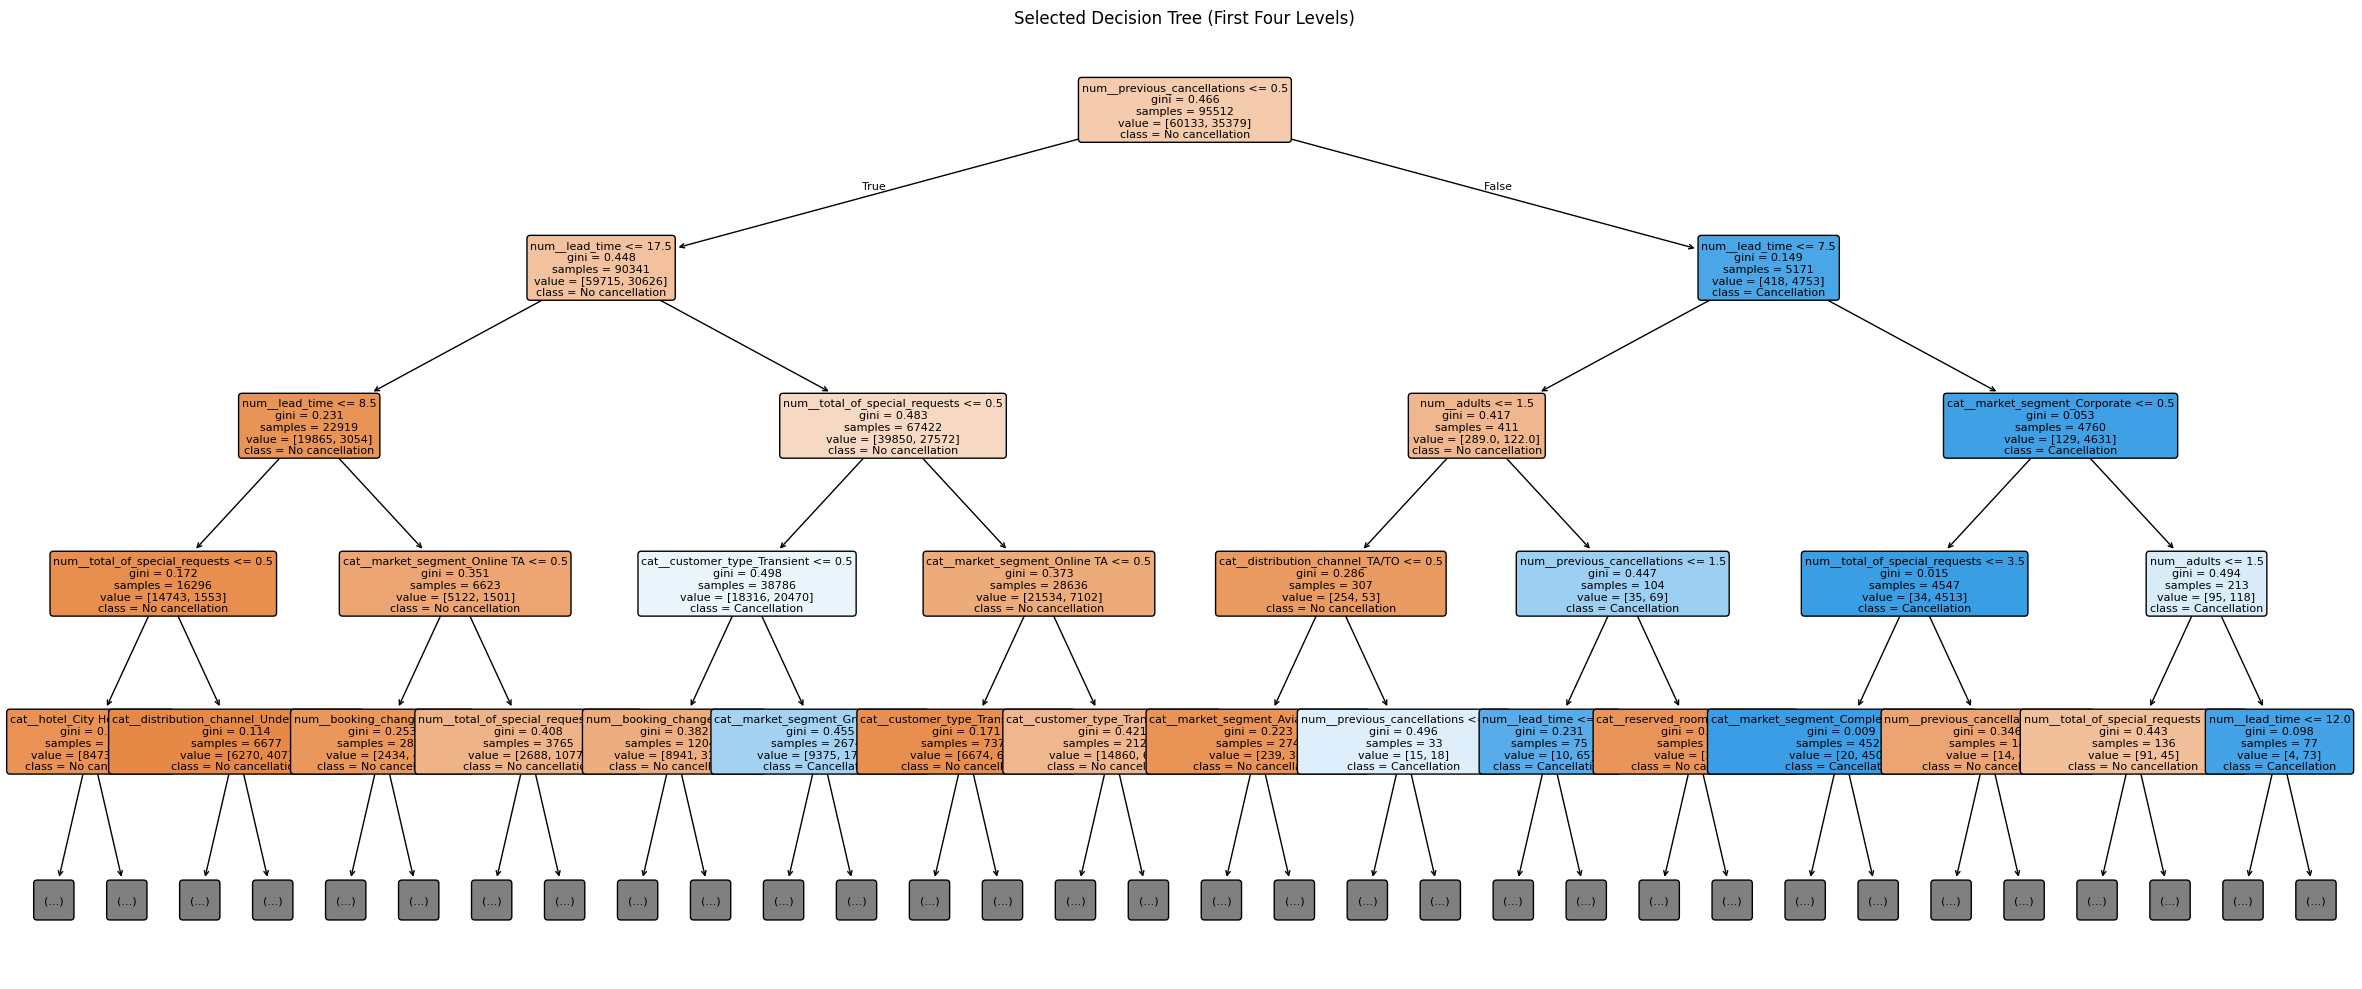

In [8]:
fitted_preprocessor = final_model.named_steps["preprocessor"]
tree_classifier = final_model.named_steps["classifier"]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

plt.figure(figsize=(24, 10))

plot_tree(
    tree_classifier,
    feature_names=transformed_feature_names,
    class_names=["No cancellation", "Cancellation"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)

plt.title("Selected Decision Tree (First Four Levels)")
plt.tight_layout()
plt.show()

Feature importance


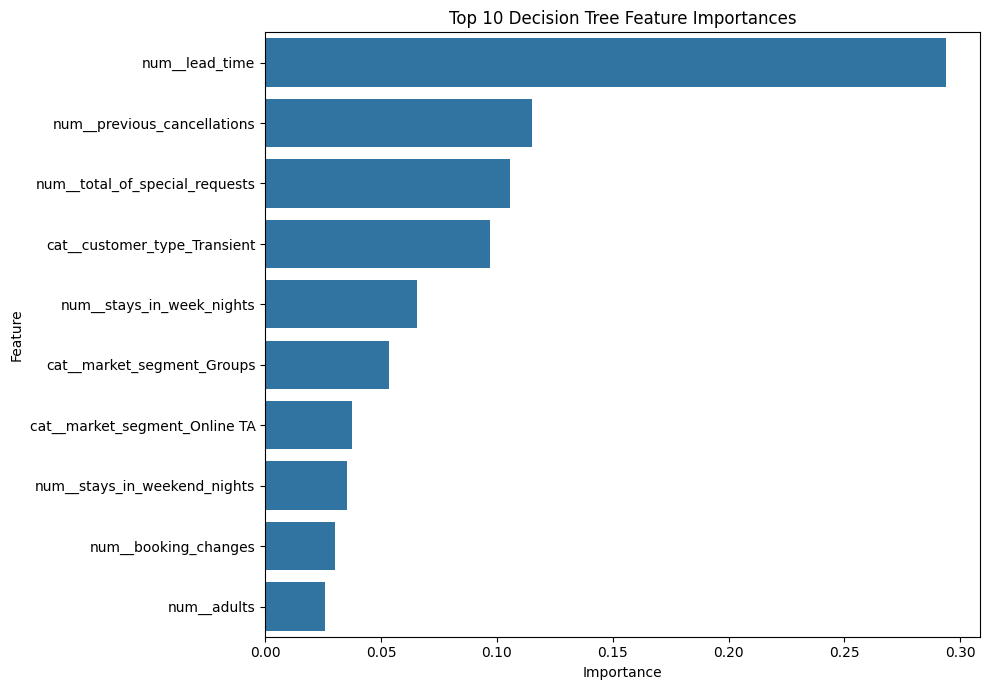

In [11]:
# Get feature importances from the trained decision tree
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
feature_values = final_model.named_steps["classifier"].feature_importances_

# Create a DataFrame
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_values
})

# Select the 15 most important features
importance = importance.sort_values(
    by="Importance", ascending=False
).head(10)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Top 10 Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

6. Extract the decision rules

In [ ]:
from sklearn.tree import export_text

# Get the trained decision tree from your pipeline
preprocessor = final_model.named_steps["preprocessor"]
tree_model = final_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Print the IF-THEN rules
rules_text = export_text(
    tree_model,
    feature_names=list(feature_names),
    max_depth=5
)

print("DECISION RULES")
print(rules_text)

7. Classify bookings using the rules

In [ ]:
import numpy as np
from sklearn.tree import _tree

# Transform test data using the same fitted preprocessing pipeline
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to array if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

tree = tree_model.tree_

def predict_from_rules(X):
    predictions = []

    for sample in X:
        node = 0

        # Follow the IF-THEN conditions to a leaf
        while tree.feature[node] != _tree.TREE_UNDEFINED:
            feature_index = tree.feature[node]
            threshold = tree.threshold[node]

            if sample[feature_index] <= threshold:
                node = tree.children_left[node]
            else:
                node = tree.children_right[node]

        # The leaf's majority class is the prediction
        class_index = np.argmax(tree.value[node][0])
        prediction = tree_model.classes_[class_index]
        predictions.append(prediction)

    return np.array(predictions)


# Predictions from both approaches
y_pred_tree = final_model.predict(X_test)
y_pred_rules = predict_from_rules(X_test_transformed)

print("Tree predictions:", y_pred_tree[:10])
print("Rule predictions:", y_pred_rules[:10])

print(
    "Predictions identical:",
    np.array_equal(y_pred_tree, y_pred_rules)
)

8. Compare the two classifiers

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(y_true, y_pred, name):
    return {
        "Classifier": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, zero_division=0
        )
    }

comparison = pd.DataFrame([
    evaluate_model(y_test, y_pred_tree, "Decision Tree"),
    evaluate_model(y_test, y_pred_rules, "Decision Rules")
])

display(comparison.round(4))

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nDecision Rules Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rules))

9. Visualize the comparison

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_long = comparison.melt(
    id_vars="Classifier",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Classifier"
)
plt.ylim(0, 1)
plt.title("Decision Tree vs Decision Rule-Based Classifier")
plt.tight_layout()
plt.show()